In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [37]:
file_path = '../Data/Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

In [38]:
# Display the first few rows of the dataframe
print("First 5 rows of the dataset:\n", df.head())

# Step 2: Check for missing values
print("\nMissing values in the dataset:\n", df.isnull().sum())


First 5 rows of the dataset:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Stream

In [39]:
print("\nSummary statistics:\n", df.describe())



Summary statistics:
        SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [40]:
print("\nUnique values in categorical columns:")
print("Gender:", df['gender'].unique())
print("InternetService:", df['InternetService'].unique())
print("Churn:", df['Churn'].unique())


Unique values in categorical columns:
Gender: ['Female' 'Male']
InternetService: ['DSL' 'Fiber optic' 'No']
Churn: ['No' 'Yes']


In [41]:

numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_columns].corr()

print("\nCorrelation matrix for numerical columns:\n", correlation_matrix)





Correlation matrix for numerical columns:
                 SeniorCitizen    tenure  MonthlyCharges
SeniorCitizen        1.000000  0.016567        0.220173
tenure               0.016567  1.000000        0.247900
MonthlyCharges       0.220173  0.247900        1.000000


In [42]:
print("\nChurn distribution:\n", df['Churn'].value_counts())


print("\nData types of columns:\n", df.dtypes)




Churn distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data types of columns:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [43]:

# Converting 'Yes'/'No' to 1/0 in relevant columns, starting with 'Churn' and 'SeniorCitizen'
df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\saika\AppData\Local\Temp\ipykernel_29888\543648260.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [44]:
# If there are more Yes/No columns that need conversion, handle them too:
yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
                  'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
                  'StreamingMovies', 'PaperlessBilling']
for col in yes_no_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})



In [51]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

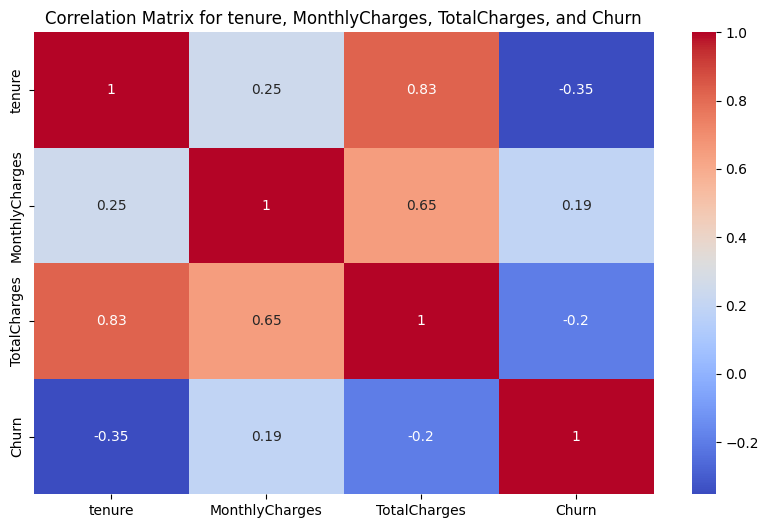

In [52]:

# Heatmap for correlation
plt.figure(figsize=(10, 6))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for tenure, MonthlyCharges, TotalCharges, and Churn')
plt.show()

In [53]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,NaN,DSL,0.0,...,0.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0.0,DSL,1.0,...,1.0,0.0,0.0,0.0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,0.0,DSL,1.0,...,0.0,0.0,0.0,0.0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,NaN,DSL,1.0,...,1.0,1.0,0.0,0.0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0.0,Fiber optic,0.0,...,0.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,70.70,151.65,1
